# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas


EOL: 1200 linhas recebidas


UHE: 221 linhas recebidas


PCH: 537 linhas recebidas


CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

### Análise exploratória dos dados da ANEEL

In [9]:
aneel = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Linhas e colunas:", aneel.shape)
print()
print(aneel.dtypes)
print()
print("Valores ausentes por coluna:")
print(aneel.isna().sum())
print()
print("Quantidade de empreendimentos por classe:")
print(aneel["fonte"].value_counts())

Linhas e colunas: (3876, 4)

potencia_kw    float64
latitude       float64
longitude      float64
fonte              str
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Quantidade de empreendimentos por classe:
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


In [10]:
aneel.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T.round(2)

fonte                 Eólica   Hidráulica      Solar
potencia_kw count    1200.00      1476.00    1200.00
            mean    30748.35     75809.16   10812.74
            std     13785.30    486419.58   17664.66
            min         0.16         0.99       0.26
            25%     23100.00       990.00       1.00
            50%     29600.00      4000.00       1.00
            75%     37200.00     17000.00   27000.00
            max    105000.00  11233100.00  137480.00
latitude    count    1200.00      1476.00    1200.00
            mean       -9.87       -21.16      -5.07
            std         7.52         6.43       5.56
            min       -33.72       -30.79     -29.84
            25%       -11.13       -26.76      -6.92
            50%        -7.98       -22.03      -2.04
            75%        -5.27       -17.65      -1.80
            max         0.00         3.80       3.83
longitude   count    1200.00      1476.00    1200.00
            mean      -39.70       -49.03     -49.45
            std         7.23         7.67       5.71
            min       -55.93       -64.65     -69.94
            25%       -41.81       -52.65     -53.07
            50%       -40.69       -50.43     -52.46
            75%       -36.49       -46.22     -45.07
            max         0.00         0.00     -35.24

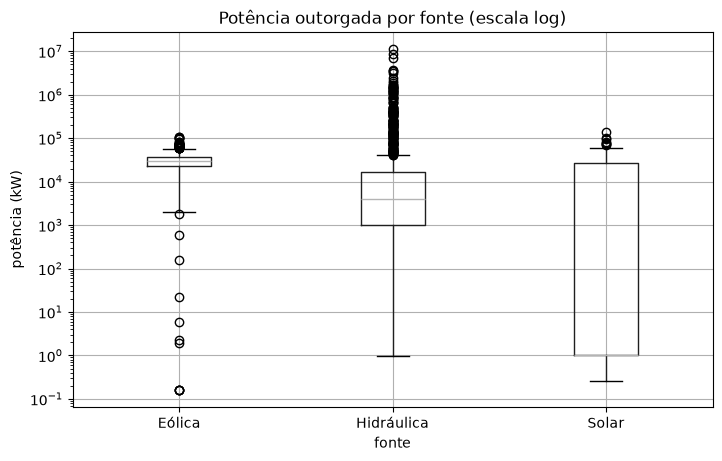

In [11]:
aneel.boxplot(column="potencia_kw", by="fonte", figsize=(8, 5))
plt.yscale("log")
plt.title("Potência outorgada por fonte (escala log)")
plt.suptitle("")
plt.xlabel("fonte")
plt.ylabel("potência (kW)")
plt.show()

O que deu para ver na exploração:

- O arquivo tem 3876 empreendimentos e nenhuma coluna tem valor ausente.
- Quantidade por classe: Hidráulica 1476, Solar 1200 e Eólica 1200. A Hidráulica junta UHE (221), PCH (537) e CGH (718). As classes estão quase equilibradas. Esse número vem do limite de 1200 registros por tipo na consulta, então não mostra quanto cada fonte representa no Brasil.
- A potência muda muito entre as fontes. A mediana da Solar é 1 kW, a da Hidráulica é 4000 kW e a da Eólica é 29600 kW. Algumas hidráulicas passam de 11 milhões de kW, por isso usei escala log no gráfico.
- A latitude também muda bastante: a mediana é -7,98 na Eólica, -22,03 na Hidráulica e -2,04 na Solar.

### Definição de X e y e divisão treino/teste

- `X`: `potencia_kw`, `latitude` e `longitude` (as três entradas numéricas).
- `y`: `fonte` (Solar, Eólica ou Hidráulica).

Não usei nome, código CEG, sigla nem descrição do empreendimento, porque esses campos entregam a resposta.

A divisão é estratificada (80% treino / 20% teste) com semente fixa (`random_state=42`), para manter a mesma proporção de classes nos dois conjuntos.

In [12]:
X_clf = aneel[["potencia_kw", "latitude", "longitude"]]
y_clf = aneel["fonte"]

X_treino_clf, X_teste_clf, y_treino_clf, y_teste_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

print("Treino:", X_treino_clf.shape, "| Teste:", X_teste_clf.shape)

Treino: (3100, 3) | Teste: (776, 3)


### Treinamento dos três classificadores

- KNN: classifica pelos vizinhos mais próximos. Como usa distância, precisa padronizar as entradas.
- Regressão Logística: modelo linear, serve de base de comparação. Também foi padronizado.
- Random Forest: conjunto de árvores de decisão, consegue separar as classes com regras não lineares e não precisa de padronização.

A padronização (`StandardScaler`) está dentro de um `Pipeline`, então ela é ajustada só com os dados de treino.

Os três modelos usam a mesma divisão treino/teste. Nas métricas por classe (Precision, Recall e F1) usei a média macro, que dá o mesmo peso para as três classes.

In [13]:
classificadores = {
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

resultados_clf = []
previsoes_clf = {}
for nome, modelo in classificadores.items():
    modelo.fit(X_treino_clf, y_treino_clf)
    y_prev = modelo.predict(X_teste_clf)
    previsoes_clf[nome] = y_prev
    resultados_clf.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste_clf, y_prev),
        "Precision (macro)": precision_score(y_teste_clf, y_prev, average="macro"),
        "Recall (macro)": recall_score(y_teste_clf, y_prev, average="macro"),
        "F1 (macro)": f1_score(y_teste_clf, y_prev, average="macro"),
    })

tabela_clf = pd.DataFrame(resultados_clf).round(3)
tabela_clf

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,KNN,0.966,0.968,0.965,0.966
1,Regressão Logística,0.823,0.828,0.820,0.818
2,Random Forest,0.977,0.978,0.976,0.977


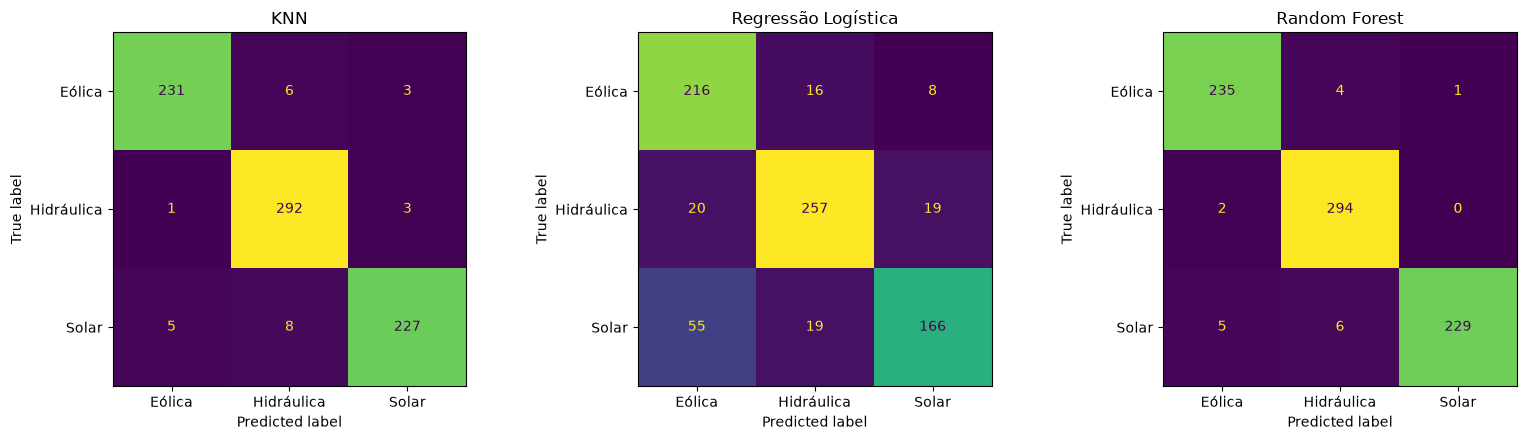

In [14]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
for eixo, (nome, y_prev) in zip(eixos, previsoes_clf.items()):
    ConfusionMatrixDisplay.from_predictions(y_teste_clf, y_prev, ax=eixo, colorbar=False)
    eixo.set_title(nome)
plt.tight_layout()
plt.show()

### Interpretação da classificação

Usei média macro em Precision, Recall e F1, porque assim cada classe tem o mesmo peso.

- A Random Forest foi a melhor, com Accuracy 0,977 e F1 0,977.
- O KNN ficou perto, com Accuracy 0,966 e F1 0,966.
- A Regressão Logística ficou bem abaixo, com Accuracy 0,823 e F1 0,818. Ela separa as classes com fronteiras lineares e aqui os dados não se separam bem desse jeito.

Eu escolheria a Random Forest, porque ela teve o melhor resultado em todas as métricas.

Classes mais confundidas:

- Na Random Forest o erro mais comum foi Solar prevista como Hidráulica (6 casos) ou como Eólica (5 casos). A Hidráulica quase não foi errada (2 casos).
- No KNN foi parecido: 8 solares previstas como Hidráulica e 5 como Eólica.
- Na Regressão Logística a maior confusão foi Solar prevista como Eólica (55 casos).

Limitações:

- O modelo só usa potência e localização. Empreendimentos de tamanho parecido e na mesma região podem ser de fontes diferentes, e é nesses casos que ele erra.
- A amostra tem no máximo 1200 registros por tipo e mistura empreendimentos em fases diferentes do cadastro, então o resultado vale para essa amostra e não para todos os empreendimentos do Brasil.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [15]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [16]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [17]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [18]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

### Análise exploratória dos dados do Open-Meteo

In [19]:
meteo = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
meteo = meteo.sort_values("data_hora").reset_index(drop=True)

print("Linhas e colunas:", meteo.shape)
print("Período:", meteo["data_hora"].min(), "até", meteo["data_hora"].max())
print()
print("Valores ausentes por coluna:")
print(meteo.isna().sum())

Linhas e colunas: (1001, 7)
Período: 2025-04-01 07:00:00 até 2025-06-30 17:00:00

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


In [20]:
meteo.describe().round(2)

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,2025-05-16 12:00:00,28.89,50.54,55.11,15.47,12.00,472.85
min,2025-04-01 07:00:00,19.50,21.00,0.00,2.30,7.00,13.00
25%,2025-04-23 15:00:00,26.30,38.00,19.00,12.20,9.00,250.00
50%,2025-05-16 12:00:00,29.10,49.00,54.00,15.40,12.00,466.00
75%,2025-06-08 09:00:00,31.70,61.00,98.00,19.00,15.00,696.00
max,2025-06-30 17:00:00,36.10,95.00,100.00,30.10,17.00,1002.00
std,NaN,3.66,15.91,37.85,4.92,3.16,256.37


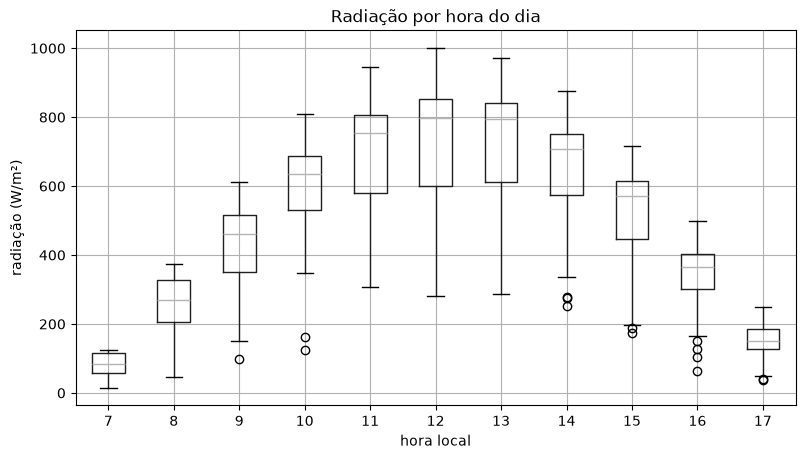

Radiação média por hora (W/m²):
hora
7      83.4
8     260.5
9     434.8
10    605.3
11    693.4
12    727.9
13    721.9
14    654.9
15    523.3
16    342.7
17    153.2
Name: radiacao_w_m2, dtype: float64

Correlação de cada entrada com a radiação:
temperatura_c    0.64
umidade_pct     -0.60
nuvens_pct      -0.18
vento_kmh       -0.23
hora             0.12
Name: radiacao_w_m2, dtype: float64


In [21]:
meteo.boxplot(column="radiacao_w_m2", by="hora", figsize=(9, 5))
plt.title("Radiação por hora do dia")
plt.suptitle("")
plt.xlabel("hora local")
plt.ylabel("radiação (W/m²)")
plt.show()

print("Radiação média por hora (W/m²):")
print(meteo.groupby("hora")["radiacao_w_m2"].mean().round(1))
print()
print("Correlação de cada entrada com a radiação:")
print(meteo.drop(columns="data_hora").corr()["radiacao_w_m2"].drop("radiacao_w_m2").round(2))

O que deu para ver na exploração:

- São 1001 horas, de 01/04/2025 às 7h até 30/06/2025 às 17h, sem valores ausentes.
- A radiação vai de 13 a 1002 W/m² e a média é 472,85 W/m².
- A radiação depende muito da hora. A média é 83,4 W/m² às 7h, sobe até 727,9 W/m² às 12h e cai para 153,2 W/m² às 17h, parecendo um sino.
- Correlação com a radiação: temperatura 0,64, umidade -0,60, vento -0,23, nuvens -0,18 e hora 0,12. A correlação da hora deu baixa porque a relação não é uma reta (sobe e depois desce), mesmo a hora sendo muito importante.

### Definição de X e y e divisão temporal

- `X`: `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`.
- `y`: `radiacao_w_m2`.

`data_hora` não entra no modelo, só serve para ordenar. Nenhuma coluna derivada da radiação foi usada como entrada.

Como os dados são uma sequência no tempo, não embaralhei: as primeiras 80% das horas ficam para treino e as últimas 20% para teste.

In [22]:
entradas = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_reg = meteo[entradas]
y_reg = meteo["radiacao_w_m2"]

corte = int(len(meteo) * 0.8)
X_treino_reg, X_teste_reg = X_reg.iloc[:corte], X_reg.iloc[corte:]
y_treino_reg, y_teste_reg = y_reg.iloc[:corte], y_reg.iloc[corte:]

print("Treino:", len(X_treino_reg), "horas, de", meteo["data_hora"].iloc[0], "até", meteo["data_hora"].iloc[corte - 1])
print("Teste: ", len(X_teste_reg), "horas, de", meteo["data_hora"].iloc[corte], "até", meteo["data_hora"].iloc[-1])

Treino: 800 horas, de 2025-04-01 07:00:00 até 2025-06-12 14:00:00
Teste:  201 horas, de 2025-06-12 15:00:00 até 2025-06-30 17:00:00


### Treinamento dos três regressores

- Regressão Linear: modelo mais simples, supõe relação linear entre as entradas e a radiação.
- Árvore de Decisão: divide os dados em regras; limitei a profundidade (`max_depth=6`) para não decorar o treino.
- Random Forest: média de várias árvores, costuma ser mais estável que uma árvore sozinha.

Os três usam a mesma divisão temporal. Nenhum desses modelos precisa de padronização.

In [23]:
regressores = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}

resultados_reg = []
previsoes_reg = {}
for nome, modelo in regressores.items():
    modelo.fit(X_treino_reg, y_treino_reg)
    y_prev = modelo.predict(X_teste_reg)
    previsoes_reg[nome] = y_prev
    resultados_reg.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_teste_reg, y_prev),
        "MSE ((W/m²)²)": mean_squared_error(y_teste_reg, y_prev),
        "R²": r2_score(y_teste_reg, y_prev),
    })

tabela_reg = pd.DataFrame(resultados_reg).round(2)
tabela_reg

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.20,30034.20,0.36
1,Árvore de Decisão,90.94,15127.03,0.68
2,Random Forest,66.25,7250.89,0.85


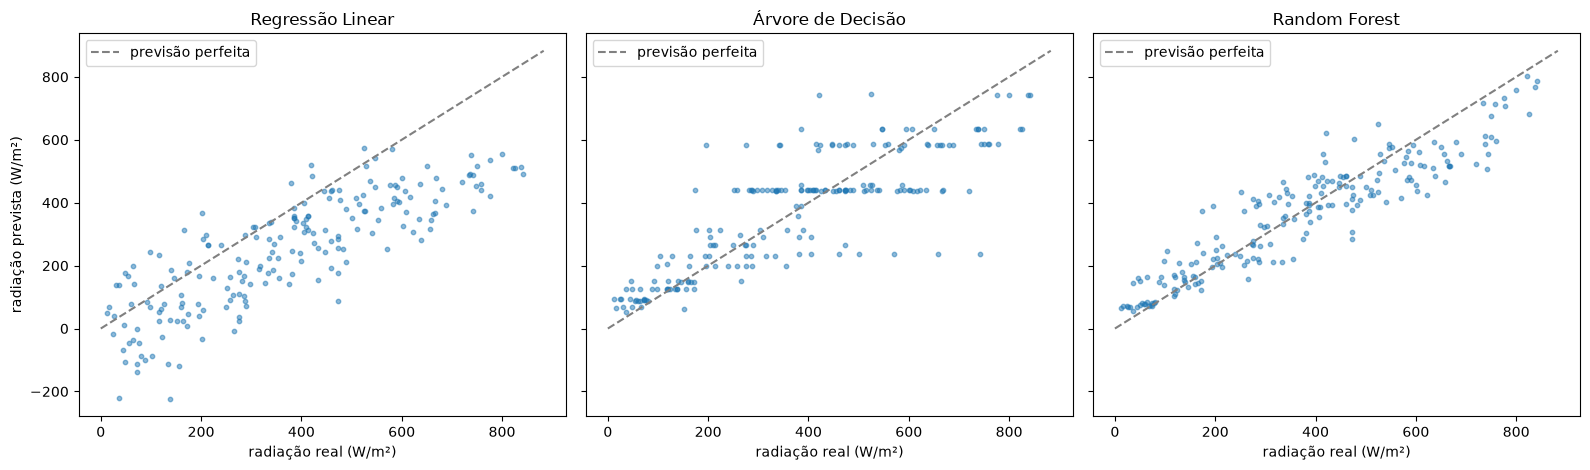

Previsões negativas da Regressão Linear: 19 de 201


In [24]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
limite = [0, max(y_teste_reg.max(), max(p.max() for p in previsoes_reg.values())) * 1.05]
for eixo, (nome, y_prev) in zip(eixos, previsoes_reg.items()):
    eixo.scatter(y_teste_reg, y_prev, s=10, alpha=0.5)
    eixo.plot(limite, limite, "--", color="gray", label="previsão perfeita")
    eixo.set_title(nome)
    eixo.set_xlabel("radiação real (W/m²)")
    eixo.legend()
eixos[0].set_ylabel("radiação prevista (W/m²)")
plt.tight_layout()
plt.show()

negativas = previsoes_reg["Regressão Linear"] < 0
print("Previsões negativas da Regressão Linear:", negativas.sum(), "de", len(negativas))

### Interpretação da regressão

Os três modelos usaram a mesma divisão no tempo.

- A Random Forest foi a melhor: MAE 66,25 W/m², MSE 7250,89 e R² 0,85.
- A Árvore de Decisão ficou em segundo: MAE 90,94 W/m², MSE 15127,03 e R² 0,68.
- A Regressão Linear foi a pior: MAE 145,20 W/m², MSE 30034,20 e R² 0,36.

O MAE de 66,25 quer dizer que a Random Forest erra em média uns 66 W/m² por hora no teste. A Regressão Linear chegou a prever radiação negativa em 19 das 201 horas do teste, o que não existe na prática.

Papel da hora:

A hora mostra a posição do sol, por isso a radiação tem formato de sino durante o dia. A Regressão Linear só consegue usar a hora como uma reta, então não representa esse sino e erra mais. A Árvore de Decisão e a Random Forest criam regras para cada faixa de hora e conseguem representar melhor esse comportamento.

Por que estimar radiação não é prever a geração elétrica:

O alvo é a radiação que chega numa superfície horizontal, em W/m², e vem de modelo e reanálise, não de um painel. A energia gerada (kWh) depende do sistema, como a área e a eficiência dos painéis, a inclinação, a temperatura, as perdas no inversor, sujeira e sombra, e ainda precisa somar ao longo do tempo. Então prever a radiação ajuda a saber o potencial solar do lugar, mas não diz sozinho quanto um sistema vai gerar.

## Conclusão

Na classificação, deu para prever bem a fonte só com potência e localização nessa amostra. A Random Forest foi a melhor (F1 0,977), depois o KNN (0,966) e por último a Regressão Logística (0,818).

Na regressão, a Random Forest também foi a melhor (MAE 66,25 W/m² e R² 0,85). A Regressão Linear (R² 0,36) não conseguiu representar o efeito da hora. O modelo estima a radiação e não a geração de energia de um sistema solar.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)